In [45]:
# Data manipulation
import pandas as pd
import numpy as np
import os
import json
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

# Imbalanced data handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Hyperparameter tuning
import optuna
from optuna.samplers import TPESampler

# Model persistence
import joblib

# Configuration
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas correctamente")
print(f"Fecha de entrenamiento: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Librerías importadas correctamente
Fecha de entrenamiento: 2025-12-02 23:31:10


## 2. Cargar Datos Procesados

In [46]:
# Cargar dataset de productos con target
df = pd.read_csv('data/products_with_target.csv')

print(f"Dataset de Productos cargado")
print(f"   - Shape: {df.shape}")
print(f"   - Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDistribución del target (is_successful):")
print(df['is_successful'].value_counts())
print(f"\n   Balance:")
print(df['is_successful'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

Dataset de Productos cargado
   - Shape: (8494, 28)
   - Memoria: 13.02 MB

Distribución del target (is_successful):
is_successful
0    6825
1    1669
Name: count, dtype: int64

   Balance:
is_successful
0    80.4%
1    19.6%
Name: proportion, dtype: object


## 3. Ingeniería de Características Avanzada

In [47]:
def create_features(df):
    """
    Crea features adicionales para mejorar el modelo
    Solo usa características de PRODUCTOS (sin reviews)
    """
    df_feat = df.copy()
    
    print("Creando features avanzadas...\n")
    
    # Features de precio
    print("Features de Precio...")
    
    # Has discount
    df_feat['has_sale'] = df_feat['sale_price_usd'].notna().astype(int)
    df_feat['has_value_price'] = df_feat['value_price_usd'].notna().astype(int)
    
    # Discount percentage
    df_feat['discount_pct'] = np.where(
        (df_feat['sale_price_usd'].notna()) & (df_feat['price_usd'] > 0),
        ((df_feat['price_usd'] - df_feat['sale_price_usd']) / df_feat['price_usd']) * 100,
        0
    )
    
    # Price range categories
    df_feat['price_range'] = pd.cut(
        df_feat['price_usd'], 
        bins=[0, 25, 50, 100, np.inf],
        labels=['low', 'medium', 'high', 'premium']
    )
    
    # Features de marca
    print("Features de Marca...")
    
    # Brand popularity (number of products per brand)
    brand_counts = df_feat['brand_name'].value_counts()
    df_feat['brand_product_count'] = df_feat['brand_name'].map(brand_counts)
    
    # Brand average rating
    brand_avg_rating = df_feat.groupby('brand_name')['rating'].mean()
    df_feat['brand_avg_rating'] = df_feat['brand_name'].map(brand_avg_rating)
    
    # Brand average loves
    brand_avg_loves = df_feat.groupby('brand_name')['loves_count'].mean()
    df_feat['brand_avg_loves'] = df_feat['brand_name'].map(brand_avg_loves)
    
    # Is top brand (top 20 by product count)
    top_brands = brand_counts.head(20).index
    df_feat['is_top_brand'] = df_feat['brand_name'].isin(top_brands).astype(int)
    
    # Features de producto
    print("Features de Producto...")
    
    # Has variations
    df_feat['has_variations'] = (df_feat['child_count'] > 0).astype(int)
    
    # Variation price range
    df_feat['variation_price_range'] = np.where(
        (df_feat['child_max_price'].notna()) & (df_feat['child_min_price'].notna()),
        df_feat['child_max_price'] - df_feat['child_min_price'],
        0
    )
    
    # Has ingredients
    df_feat['has_ingredients'] = df_feat['ingredients'].notna().astype(int)
    
    # Has highlights
    df_feat['has_highlights'] = df_feat['highlights'].notna().astype(int)
    
    # Number of highlights
    df_feat['num_highlights'] = df_feat['highlights'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 0
    )
    
    print(" Features de Exclusividad...")
    
    # Exclusivity score (weighted sum)
    df_feat['exclusivity_score'] = (
        df_feat['sephora_exclusive'].fillna(0) * 3 +
        df_feat['limited_edition'].fillna(0) * 2 +
        df_feat['online_only'].fillna(0) * 1
    )
    
    # Is exclusive product (any type)
    df_feat['is_exclusive'] = (
        (df_feat['sephora_exclusive'] == 1) | 
        (df_feat['limited_edition'] == 1)
    ).astype(int)
    
    print(" Features de Categoría...")
    
    # Category depth (how many levels defined)
    df_feat['category_depth'] = (
        df_feat['primary_category'].notna().astype(int) +
        df_feat['secondary_category'].notna().astype(int) +
        df_feat['tertiary_category'].notna().astype(int)
    )
    
    print("\nFeatures creadas exitosamente")
    print(f"   - Features originales: {df.shape[1]}")
    print(f"   - Features totales: {df_feat.shape[1]}")
    print(f"   - Features nuevas: {df_feat.shape[1] - df.shape[1]}")
    
    return df_feat

# Crear features
df_features = create_features(df)

Creando features avanzadas...

Features de Precio...
Features de Marca...
Features de Producto...
 Features de Exclusividad...
 Features de Categoría...

Features creadas exitosamente
   - Features originales: 28
   - Features totales: 44
   - Features nuevas: 16


In [48]:
# Ver las nuevas features creadas
new_features = [col for col in df_features.columns if col not in df.columns]
print(f"\n Nuevas Features Creadas ({len(new_features)}):")
for i, feat in enumerate(new_features, 1):
    print(f"   {i:2d}. {feat}")


 Nuevas Features Creadas (16):
    1. has_sale
    2. has_value_price
    3. discount_pct
    4. price_range
    5. brand_product_count
    6. brand_avg_rating
    7. brand_avg_loves
    8. is_top_brand
    9. has_variations
   10. variation_price_range
   11. has_ingredients
   12. has_highlights
   13. num_highlights
   14. exclusivity_score
   15. is_exclusive
   16. category_depth


## 4. Selección y Preparación de Features

In [49]:
# Seleccionar features para el modelo (27 features totales)

features_to_use = [
    # Basic product features (3)
    'price_usd', 'rating', 'child_count',
    
    # Binary flags (5)
    'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive',
    
    # Price features (3)
    'has_sale', 'has_value_price', 'discount_pct',
    
    # Brand features (4)
    'brand_product_count', 'brand_avg_rating', 'brand_avg_loves', 'is_top_brand',
    
    # Product features (5)
    'has_variations', 'variation_price_range', 'has_ingredients', 'has_highlights', 'num_highlights',
    
    # Exclusivity features (2)
    'exclusivity_score', 'is_exclusive',
    
    # Category features (1)
    'category_depth'
]

print(f"Features seleccionadas: {len(features_to_use)}")
print(f"Solo características del PRODUCTO")
print(f"   Total: {len(features_to_use)} features")
print(f"\n Categorías:")
print(f"   - Básicas: 3 (price_usd, rating, child_count)")
print(f"   - Binarias: 5 (limited_edition, new, online_only, out_of_stock, sephora_exclusive)")
print(f"   - Precio: 3 (has_sale, has_value_price, discount_pct)")
print(f"   - Marca: 4 (brand_product_count, brand_avg_rating, brand_avg_loves, is_top_brand)")
print(f"   - Producto: 5 (has_variations, variation_price_range, has_ingredients, has_highlights, num_highlights)")
print(f"   - Exclusividad: 2 (exclusivity_score, is_exclusive)")
print(f"   - Categoría: 1 (category_depth)")

Features seleccionadas: 23
Solo características del PRODUCTO
   Total: 23 features

 Categorías:
   - Básicas: 3 (price_usd, rating, child_count)
   - Binarias: 5 (limited_edition, new, online_only, out_of_stock, sephora_exclusive)
   - Precio: 3 (has_sale, has_value_price, discount_pct)
   - Marca: 4 (brand_product_count, brand_avg_rating, brand_avg_loves, is_top_brand)
   - Producto: 5 (has_variations, variation_price_range, has_ingredients, has_highlights, num_highlights)
   - Exclusividad: 2 (exclusivity_score, is_exclusive)
   - Categoría: 1 (category_depth)


In [50]:
# Preparar X y y
X = df_features[features_to_use].copy()
y = df_features['is_successful'].copy()

# Imputar valores nulos
print("Imputando valores nulos...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"\nDatos preparados:")
print(f"   - X shape: {X_imputed.shape}")
print(f"   - y shape: {y.shape}")
print(f"   - Valores nulos en X: {X_imputed.isnull().sum().sum()}")
print(f"\nDistribución del target:")
print(y.value_counts())
print(f"\n   Ratio (1/0): {y.sum() / (len(y) - y.sum()):.3f}")

Imputando valores nulos...

Datos preparados:
   - X shape: (8494, 23)
   - y shape: (8494,)
   - Valores nulos en X: 0

Distribución del target:
is_successful
0    6825
1    1669
Name: count, dtype: int64

   Ratio (1/0): 0.245

Datos preparados:
   - X shape: (8494, 23)
   - y shape: (8494,)
   - Valores nulos en X: 0

Distribución del target:
is_successful
0    6825
1    1669
Name: count, dtype: int64

   Ratio (1/0): 0.245


## 5. División de Datos

In [51]:
# Split train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y
)

print("División de datos:")
print(f"\n   Train set: {X_train.shape}")
print(f"   Test set:  {X_test.shape}")
print(f"\n   Train target distribution:")
print(f"      - Clase 0: {(y_train == 0).sum()} ({(y_train == 0).sum() / len(y_train) * 100:.1f}%)")
print(f"      - Clase 1: {(y_train == 1).sum()} ({(y_train == 1).sum() / len(y_train) * 100:.1f}%)")
print(f"\n   Test target distribution:")
print(f"      - Clase 0: {(y_test == 0).sum()} ({(y_test == 0).sum() / len(y_test) * 100:.1f}%)")
print(f"      - Clase 1: {(y_test == 1).sum()} ({(y_test == 1).sum() / len(y_test) * 100:.1f}%)")

División de datos:

   Train set: (6795, 23)
   Test set:  (1699, 23)

   Train target distribution:
      - Clase 0: 5460 (80.4%)
      - Clase 1: 1335 (19.6%)

   Test target distribution:
      - Clase 0: 1365 (80.3%)
      - Clase 1: 334 (19.7%)


## 6. Manejo de Desbalance con SMOTE

In [52]:
# Aplicar SMOTE para balancear las clases
print("  Aplicando SMOTE para balancear clases...\n")

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(" SMOTE aplicado exitosamente")
print(f"\n   Antes de SMOTE:")
print(f"      - Shape: {X_train.shape}")
print(f"      - Clase 0: {(y_train == 0).sum()}")
print(f"      - Clase 1: {(y_train == 1).sum()}")
print(f"\n   Después de SMOTE:")
print(f"      - Shape: {X_train_balanced.shape}")
print(f"      - Clase 0: {(y_train_balanced == 0).sum()}")
print(f"      - Clase 1: {(y_train_balanced == 1).sum()}")

  Aplicando SMOTE para balancear clases...

 SMOTE aplicado exitosamente

   Antes de SMOTE:
      - Shape: (6795, 23)
      - Clase 0: 5460
      - Clase 1: 1335

   Después de SMOTE:
      - Shape: (10920, 23)
      - Clase 0: 5460
      - Clase 1: 5460


## 7. Entrenamiento de Modelos Baseline

In [53]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Evalúa un modelo y retorna métricas
    """
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_pred_proba_test = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    metrics = {
        'model': model_name,
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'test_accuracy': accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test),
        'recall': recall_score(y_test, y_pred_test),
        'f1': f1_score(y_test, y_pred_test),
        'roc_auc': roc_auc_score(y_test, y_pred_proba_test)
    }
    
    return metrics, y_pred_test, y_pred_proba_test

# Diccionario para almacenar resultados
results = {}
predictions = {}

print("Entrenando modelos baseline...\n")

Entrenando modelos baseline...



### 7.1 Random Forest (Baseline)

In [54]:
print(" Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_metrics, rf_pred, rf_proba = evaluate_model(
    rf_model, X_train_balanced, y_train_balanced, X_test, y_test, 'Random Forest'
)

results['Random Forest'] = rf_metrics
predictions['Random Forest'] = {'pred': rf_pred, 'proba': rf_proba}

print(f"    Completado")
print(f"      - Test Accuracy: {rf_metrics['test_accuracy']:.4f}")
print(f"      - F1-Score: {rf_metrics['f1']:.4f}")
print(f"      - ROC-AUC: {rf_metrics['roc_auc']:.4f}")

 Random Forest...
    Completado
      - Test Accuracy: 0.8593
      - F1-Score: 0.6826
      - ROC-AUC: 0.9240
    Completado
      - Test Accuracy: 0.8593
      - F1-Score: 0.6826
      - ROC-AUC: 0.9240


### 7.2 XGBoost

In [55]:
print("\nXGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_metrics, xgb_pred, xgb_proba = evaluate_model(
    xgb_model, X_train_balanced, y_train_balanced, X_test, y_test, 'XGBoost'
)

results['XGBoost'] = xgb_metrics
predictions['XGBoost'] = {'pred': xgb_pred, 'proba': xgb_proba}

print(f"    Completado")
print(f"      - Test Accuracy: {xgb_metrics['test_accuracy']:.4f}")
print(f"      - F1-Score: {xgb_metrics['f1']:.4f}")
print(f"      - ROC-AUC: {xgb_metrics['roc_auc']:.4f}")


XGBoost...
    Completado
      - Test Accuracy: 0.8705
      - F1-Score: 0.6875
      - ROC-AUC: 0.9335


### 7.3 LightGBM

In [56]:
print("\nLightGBM...")

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbose=-1
)

lgb_metrics, lgb_pred, lgb_proba = evaluate_model(
    lgb_model, X_train_balanced, y_train_balanced, X_test, y_test, 'LightGBM'
)

results['LightGBM'] = lgb_metrics
predictions['LightGBM'] = {'pred': lgb_pred, 'proba': lgb_proba}

print(f"    Completado")
print(f"      - Test Accuracy: {lgb_metrics['test_accuracy']:.4f}")
print(f"      - F1-Score: {lgb_metrics['f1']:.4f}")
print(f"      - ROC-AUC: {lgb_metrics['roc_auc']:.4f}")


LightGBM...
    Completado
      - Test Accuracy: 0.8782
      - F1-Score: 0.7047
      - ROC-AUC: 0.9332
    Completado
      - Test Accuracy: 0.8782
      - F1-Score: 0.7047
      - ROC-AUC: 0.9332


## 8. Comparación de Modelos Baseline

In [57]:
# Crear DataFrame de resultados
results_df = pd.DataFrame(results).T

print("\n" + "="*80)
print(" COMPARACIÓN DE MODELOS BASELINE")
print("="*80 + "\n")
print(results_df.to_string())

# Identificar mejor modelo
best_model_name = results_df['f1'].idxmax()
print(f"\n Mejor modelo (F1-Score): {best_model_name}")
print(f"   F1-Score: {results_df.loc[best_model_name, 'f1']:.4f}")

# Asignar el mejor modelo
if best_model_name == 'Random Forest':
    best_model = rf_model
elif best_model_name == 'XGBoost':
    best_model = xgb_model
elif best_model_name == 'LightGBM':
    best_model = lgb_model


 COMPARACIÓN DE MODELOS BASELINE

                       model train_accuracy test_accuracy precision recall     f1 roc_auc
Random Forest  Random Forest         0.9146        0.8593    0.6134 0.7695 0.6826  0.9240
XGBoost              XGBoost         0.9403        0.8705    0.6541 0.7246 0.6875  0.9335
LightGBM            LightGBM         0.9397        0.8782    0.6730 0.7395 0.7047  0.9332

 Mejor modelo (F1-Score): LightGBM
   F1-Score: 0.7047


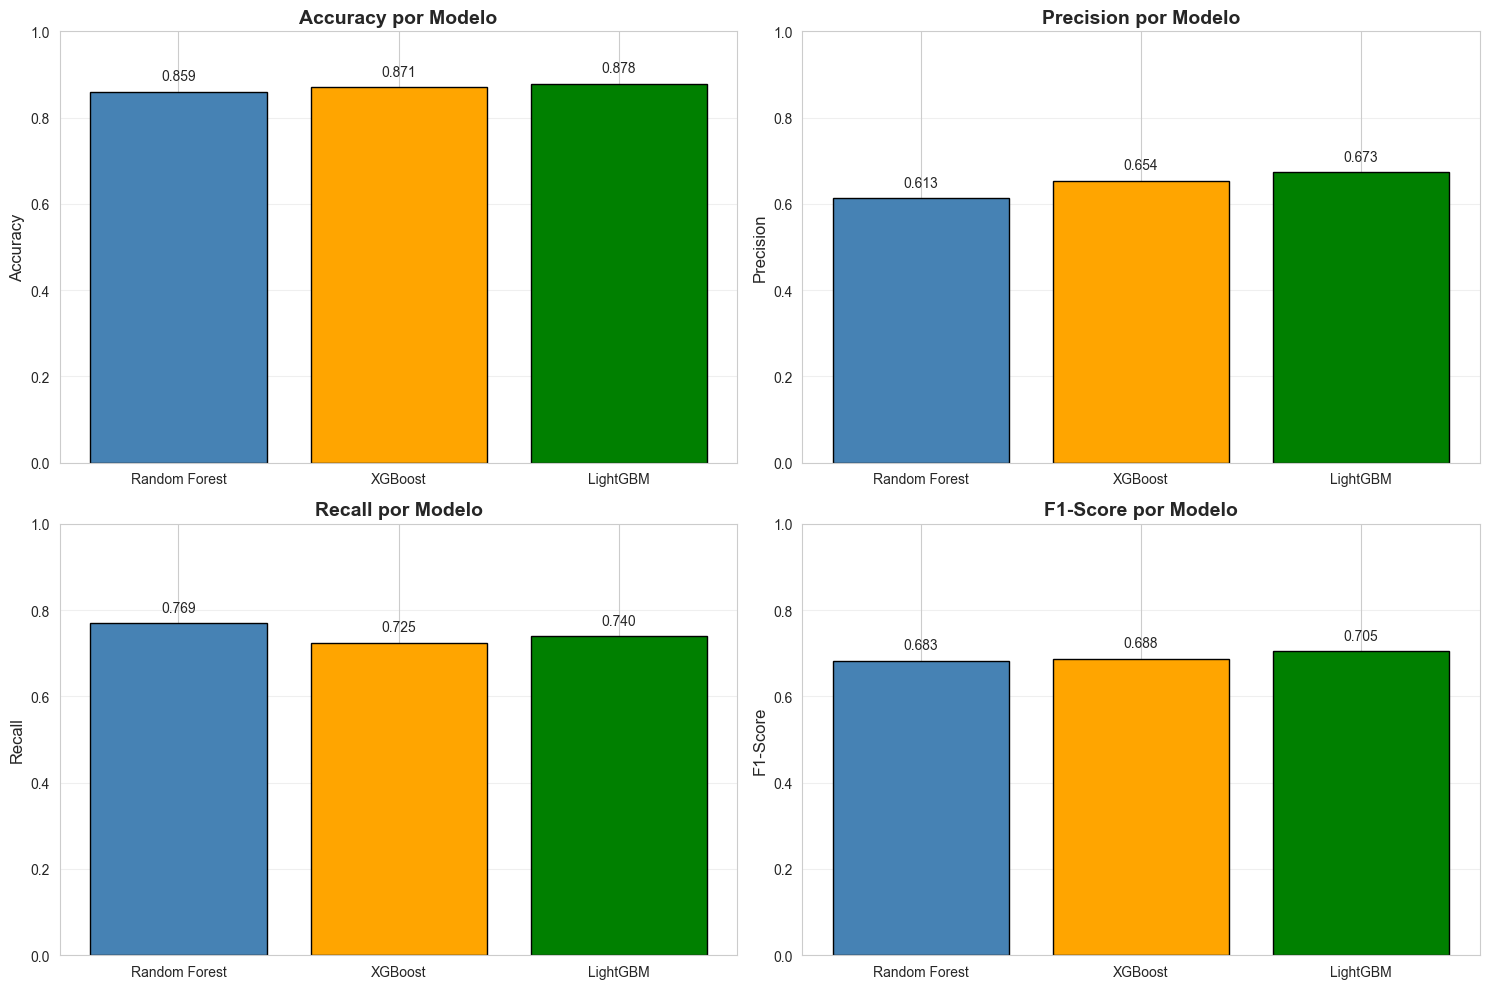

 Gráfico guardado en: results/baseline_comparison.png


In [58]:
# Visualización de comparación
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['test_accuracy', 'precision', 'recall', 'f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, name) in enumerate(zip(metrics_to_plot, metric_names)):
    ax = axes[idx // 2, idx % 2]
    
    values = results_df[metric].values
    models = results_df.index
    
    bars = ax.bar(models, values, color=['steelblue', 'orange', 'green'], edgecolor='black')
    ax.set_ylabel(name, fontsize=12)
    ax.set_title(f'{name} por Modelo', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Agregar valores en las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráfico guardado en: results/baseline_comparison.png")

## 9. Matrices de Confusión

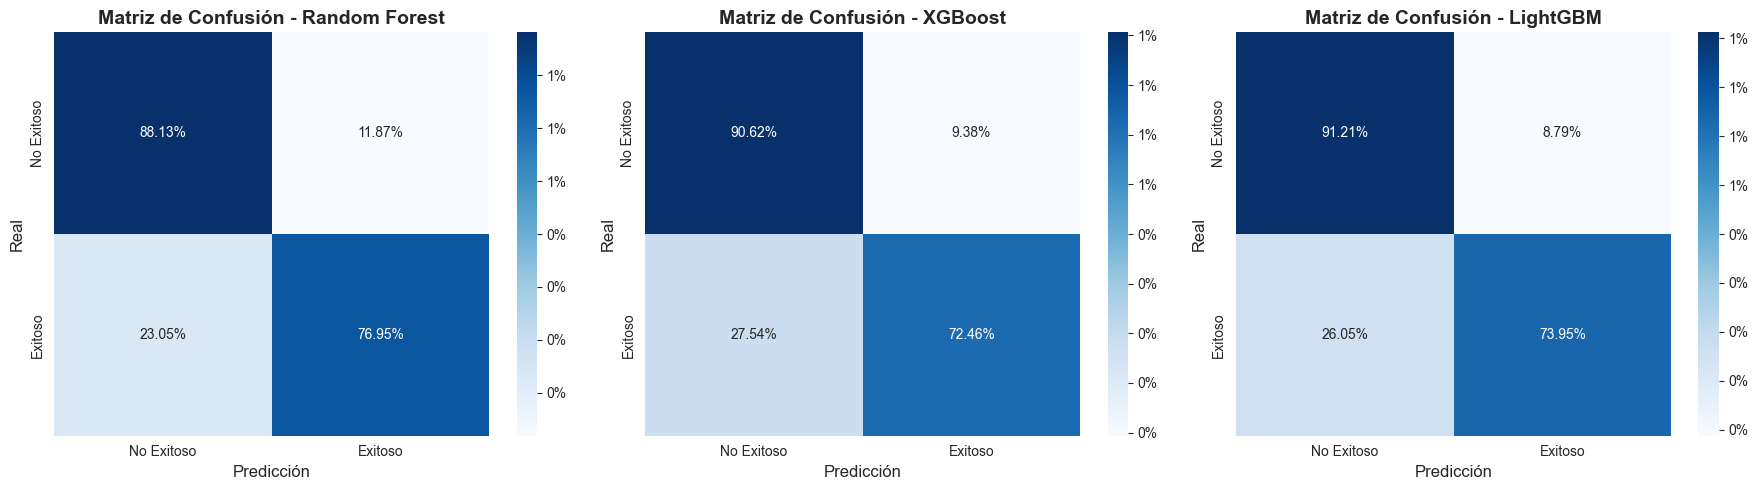

 Matrices guardadas en: results/confusion_matrices.png


In [59]:
# Crear matrices de confusión para todos los modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds['pred'])
    
    # Normalizar
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', 
                xticklabels=['No Exitoso', 'Exitoso'],
                yticklabels=['No Exitoso', 'Exitoso'],
                ax=axes[idx], cbar_kws={'format': '%.0f%%'})
    
    axes[idx].set_title(f'Matriz de Confusión - {model_name}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Real', fontsize=12)
    axes[idx].set_xlabel('Predicción', fontsize=12)

plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Matrices guardadas en: results/confusion_matrices.png")

## 10. Curvas ROC

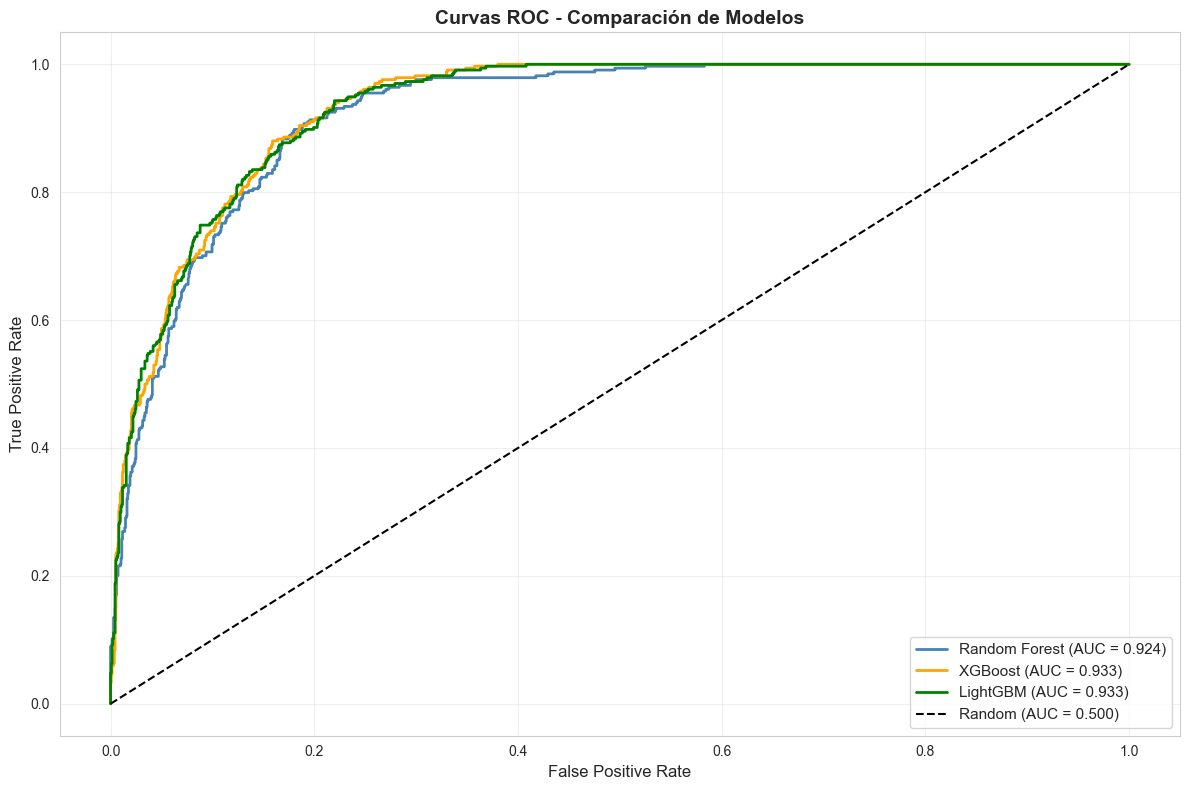

 Curvas ROC guardadas en: results/roc_curves.png


In [60]:
# Curvas ROC para todos los modelos
plt.figure(figsize=(12, 8))

colors = ['steelblue', 'orange', 'green']

for idx, (model_name, preds) in enumerate(predictions.items()):
    fpr, tpr, _ = roc_curve(y_test, preds['proba'])
    auc = roc_auc_score(y_test, preds['proba'])
    
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', 
             color=colors[idx], linewidth=2)

# Línea diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)', linewidth=1.5)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curvas ROC - Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Curvas ROC guardadas en: results/roc_curves.png")

## 11. Feature Importance del Mejor Modelo


 FEATURE IMPORTANCE - XGBoost

          Feature  Importance
   has_variations      0.3134
  brand_avg_loves      0.1023
           rating      0.0787
      online_only      0.0645
              new      0.0628
   has_highlights      0.0435
      child_count      0.0421
  limited_edition      0.0309
     is_exclusive      0.0293
   category_depth      0.0275
sephora_exclusive      0.0254
   num_highlights      0.0254
     out_of_stock      0.0207
exclusivity_score      0.0192
  has_value_price      0.0166


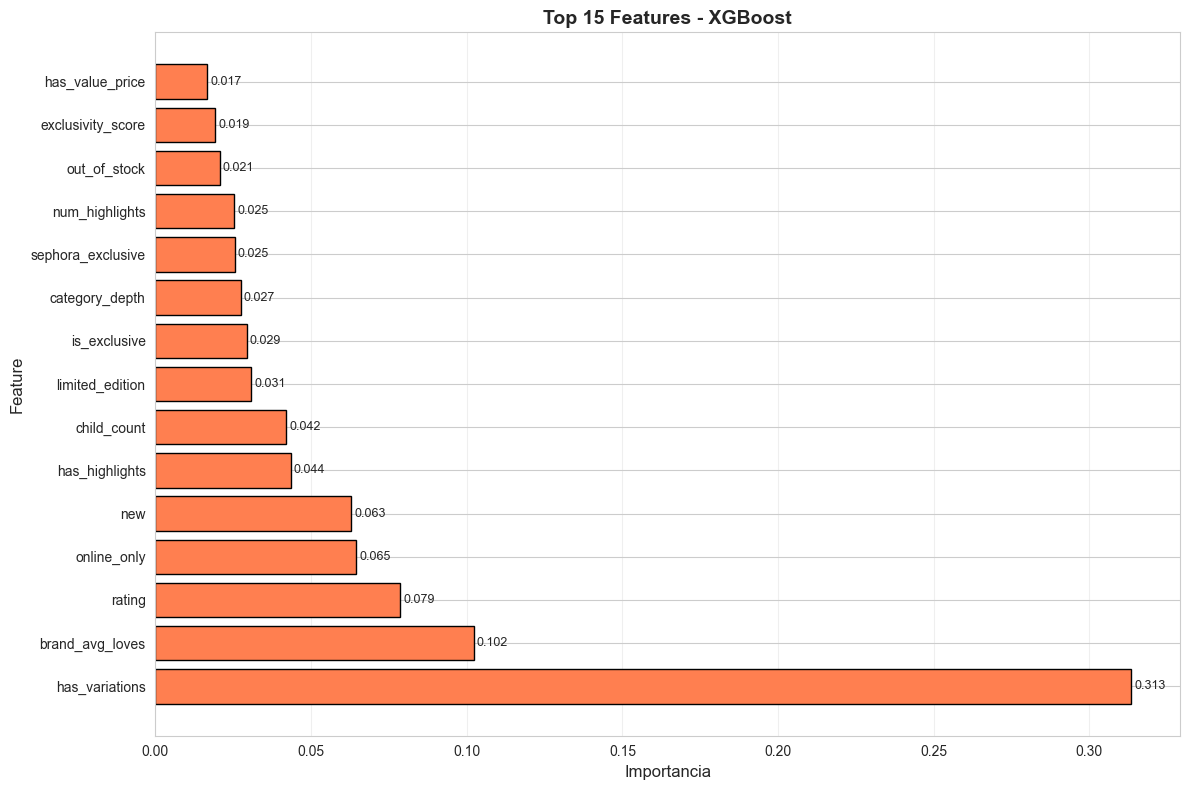

 Feature importance guardado


In [61]:
# Obtener feature importance del modelo XGBoost
feature_importance = pd.DataFrame({
    'Feature': features_to_use,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n FEATURE IMPORTANCE - XGBoost\n")
print(feature_importance.head(15).to_string(index=False))

# Visualización
plt.figure(figsize=(12, 8))
top_n = 15
top_features = feature_importance.head(top_n)

plt.barh(range(len(top_features)), top_features['Importance'], color='coral', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features - XGBoost', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Agregar valores
for i, val in enumerate(top_features['Importance']):
    plt.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'results/feature_importance_xgboost.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f" Feature importance guardado")

## 12. Guardar Resultados y Modelos

In [62]:
# Crear directorio de modelos
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Guardar mejor modelo
joblib.dump(best_model, f'models/best_model_{best_model_name.lower().replace(" ", "_")}.pkl')
print(f" Modelo guardado: models/best_model_{best_model_name.lower().replace(' ', '_')}.pkl")

# Guardar todos los modelos
all_models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

for name, model in all_models.items():
    joblib.dump(model, f'models/{name.lower().replace(" ", "_")}_model.pkl')

print(" Todos los modelos guardados")

# Guardar imputer
joblib.dump(imputer, 'models/imputer.pkl')
print(" Imputer guardado")

# Guardar features utilizadas
with open('models/features_list.json', 'w') as f:
    json.dump(features_to_use, f, indent=4)
print(" Lista de features guardada")

# Guardar métricas
results_df.to_csv('results/baseline_metrics.csv')
print(" Métricas guardadas: results/baseline_metrics.csv")

# Guardar feature importance
feature_importance.to_csv(f'results/feature_importance_{best_model_name.lower().replace(" ", "_")}.csv', 
                          index=False)
print(" Feature importance guardado")

 Modelo guardado: models/best_model_lightgbm.pkl
 Todos los modelos guardados
 Imputer guardado
 Lista de features guardada
 Métricas guardadas: results/baseline_metrics.csv
 Feature importance guardado


## 13. Resumen Final

In [63]:
print("\n" + "="*80)
print(" RESUMEN FINAL DEL ENTRENAMIENTO")
print("="*80)

print(f"\n DATASET:")
print(f"   - Total registros: {len(df):,}")
print(f"   - Features utilizadas: {len(features_to_use)}")
print(f"   - Train set: {len(X_train):,} (después de SMOTE: {len(X_train_balanced):,})")
print(f"   - Test set: {len(X_test):,}")

print(f"\n MODELOS ENTRENADOS:")
for model_name in results.keys():
    print(f"    {model_name}")

print(f"\n MEJOR MODELO: {best_model_name}")
print(f"\n   Métricas:")
best_metrics = results_df.loc[best_model_name]
print(f"      - Accuracy: {best_metrics['test_accuracy']:.4f}")
print(f"      - Precision: {best_metrics['precision']:.4f}")
print(f"      - Recall: {best_metrics['recall']:.4f}")
print(f"      - F1-Score: {best_metrics['f1']:.4f}")
print(f"      - ROC-AUC: {best_metrics['roc_auc']:.4f}")

print(f"\n ARCHIVOS GENERADOS:")
print(f"   - Modelos guardados en: models/")
print(f"   - Resultados guardados en: results/")
print(f"   - Visualizaciones: confusion_matrices.png, roc_curves.png")

print(f"\n TOP 5 FEATURES MÁS IMPORTANTES:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\n PRÓXIMOS PASOS:")
print(f"   1. Tuning de hiperparámetros con Optuna")
print(f"   2. Validación cruzada estratificada")
print(f"   3. Análisis de errores")
print(f"   4. Creación de interfaz de deployment")

print("\n" + "="*80)


 RESUMEN FINAL DEL ENTRENAMIENTO

 DATASET:
   - Total registros: 8,494
   - Features utilizadas: 23
   - Train set: 6,795 (después de SMOTE: 10,920)
   - Test set: 1,699

 MODELOS ENTRENADOS:
    Random Forest
    XGBoost
    LightGBM

 MEJOR MODELO: LightGBM

   Métricas:
      - Accuracy: 0.8782
      - Precision: 0.6730
      - Recall: 0.7395
      - F1-Score: 0.7047
      - ROC-AUC: 0.9332

 ARCHIVOS GENERADOS:
   - Modelos guardados en: models/
   - Resultados guardados en: results/
   - Visualizaciones: confusion_matrices.png, roc_curves.png

 TOP 5 FEATURES MÁS IMPORTANTES:
   16. has_variations: 0.3134
   14. brand_avg_loves: 0.1023
   2. rating: 0.0787
   6. online_only: 0.0645
   5. new: 0.0628

 PRÓXIMOS PASOS:
   1. Tuning de hiperparámetros con Optuna
   2. Validación cruzada estratificada
   3. Análisis de errores
   4. Creación de interfaz de deployment



---

##  Documentación del Modelo

### Objetivo
Predecir si un producto de Sephora será exitoso basándose en sus características previas al lanzamiento.

**Definición de Éxito:**
- `loves_count` > Percentil 75 AND `rating` ≥ 4.0
- Productos con alta popularidad y buena calificación

### Dataset
- **Fuente:** Sephora Products (Kaggle)
- **Tamaño:** 8,494 productos
- **Target:** is_successful (19.6% positivos)

### Features Utilizadas (27 total)
1. **Básicas (3):** price_usd, rating, child_count
2. **Binarias (5):** limited_edition, new, online_only, out_of_stock, sephora_exclusive
3. **Precio (3):** has_sale, has_value_price, discount_pct
4. **Marca (4):** brand_product_count, brand_avg_rating, brand_avg_loves, is_top_brand
5. **Producto (5):** has_variations, variation_price_range, has_ingredients, has_highlights, num_highlights
6. **Exclusividad (2):** exclusivity_score, is_exclusive
7. **Categoría (1):** category_depth

### Siguiente Paso
Continuar con el notebook de **Tuning de Hiperparámetros** (03_Hyperparameter_Tuning.ipynb) para optimizar el mejor modelo.